In [ ]:
%pip -q install timm==0.9.12 kornia==0.7.2 grad-cam --no-warn-script-location
%pip -q install scikit-learn==1.5.1 matplotlib==3.8.4 --no-warn-script-location

import os, sys, math, gc, time, random, json, psutil, itertools, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import kornia as K
import kornia.augmentation as KA

from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix
)

import torchvision.transforms as T

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s); torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
set_seed()

assert torch.cuda.is_available(), "CUDA not available. Enable GPU."
n_gpus = torch.cuda.device_count()
print(f"GPUs: {n_gpus} -> {[torch.cuda.get_device_name(i) for i in range(n_gpus)]}")

device = torch.device("cuda:0")


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

GPUs: 2 -> ['Tesla T4', 'Tesla T4']


In [ ]:

CLASSES = [
    "diabetic_retinopathy",
    "media_hazy",
    "myopic_retinopathy",
    "normal",
    "optic_disc_disorder",
]
CLASS_TO_IDX = {c:i for i,c in enumerate(CLASSES)}
IDX_TO_CLASS = {i:c for c,i in CLASS_TO_IDX.items()}
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

CFG = dict(
    seed=SEED,
    img_size=224,
    num_classes=len(CLASSES),

    epochs=60,
    init_lr=2e-4,
    warmup_pct=0.10,
    min_lr_ratio=0.25,
    weight_decay=0.05,
    drop_path=0.20,
    label_smoothing=0.10,
    focal_gamma=1.5,

    batch_size_start=128,
    batch_size_min=64,
    microbatch_max_gpu=128,
    eval_microbatch=128,
    accum_steps=1,
    early_stop_patience=10,
    num_workers=max(2, psutil.cpu_count(logical=True)//2),
    prefetch_factor=4,
    pin_memory=True,
    persistent_workers=True,

    use_mixup=True,
    mixup_alpha=0.20,
    mixup_p=0.70,
    mixup_ramp_epochs=5,

    cutmix_p=0.30,
    cutmix_alpha=1.0,
    random_erasing_p=0.20,

    branch_drop_p=0.10,
    branch_drop_ramp_epochs=4,
    branch2_freeze_epochs=2,

    grad_clip_norm=1.0,
    ema_decay=0.995,
    use_compile=False,

    use_torchvision_backbones=True,
    tv_pretrained=True,
    torchvision_models=["efficientnet_b3", "convnext_tiny"],
    hybrid_w_init=[0.55, 0.45],

    target_per_class=1200,

    val_tta=1,
    test_tta=4,
    monitor_per_class=40,

    branch_parallel=True,
    amp=True,
    channels_last=True,
    offline_mode=False,
    best_ckpt_path="best_model.pth",

    swa_enable=True,
    swa_start_epoch_frac=0.7,
    swa_lr=1e-4,
    disk_cache_dir="/kaggle/working/fundus_cache",

    min_label_smoothing=0.08,
    target_train_acc=0.95,
    reg_boost_step=0.20,
    reg_boost_max=1.80,
    cp_base=0.00,
    cp_step=0.012,
    cp_max=0.04,

    use_sam=True,
    sam_rho=0.05,
    sam_adaptive=True,
)


In [ ]:

    def _square_pad_resize_np(np_img: np.ndarray, size: int) -> np.ndarray:
        h, w = np_img.shape[:2]
        side = max(h, w)
        base = np.zeros((side, side, 3), dtype=np.uint8)
        y0 = (side - h)//2; x0 = (side - w)//2
        base[y0:y0+h, x0:x0+w] = np_img
        return np.array(Image.fromarray(base).resize((size, size), Image.BILINEAR))

    class DiskCacheFundusDataset(Dataset):
        def __init__(self, df, img_size=224):
            self.df = df.reset_index(drop=True)
            self.size = int(img_size)
        def __len__(self): return len(self.df)
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img = Image.open(row["path"]).convert("RGB")
            np_img = np.array(img)
            np_img = _square_pad_resize_np(np_img, self.size)
            x = torch.from_numpy(np_img).permute(2,0,1).float() / 255.0
            y = int(row["target"])
            return x, y

def index_dataset(root: str, class_list):
    exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.tif","*.tiff")
    rows = []
    for cls in class_list:
        folder = os.path.join(root, cls)
        if not os.path.isdir(folder):
            raise FileNotFoundError(f"Missing folder: {folder}")
        for e in exts:
            for p in glob.glob(os.path.join(folder, "**", e), recursive=True):
                rows.append({"path": p, "label": cls})
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f"No images found under {root} for classes: {class_list}")
    df["target"] = df["label"].map(CLASS_TO_IDX).astype(int)
    return df

all_df = index_dataset(DATA_ROOT, CLASSES).sample(frac=1.0, random_state=CFG["seed"]).reset_index(drop=True)
print(f"Indexed files: {len(all_df)}")
print("Per-class counts:", all_df["label"].value_counts().to_dict())

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=CFG["seed"])
train_idx, hold_idx = next(sss1.split(all_df["path"], all_df["target"]))
train_df = all_df.iloc[train_idx].reset_index(drop=True)
hold_df  = all_df.iloc[hold_idx].reset_index(drop=True)

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=CFG["seed"])
val_idx, test_idx = next(sss2.split(hold_df["path"], hold_df["target"]))
val_df  = hold_df.iloc[val_idx].reset_index(drop=True)
test_df = hold_df.iloc[test_idx].reset_index(drop=True)

print("Split sizes:", { "train": len(train_df), "val": len(val_df), "test": len(test_df) })

def effective_num_weights(counts: np.ndarray, beta=0.999):
    en = (1.0 - np.power(beta, counts)) / (1.0 - beta)
    w = 1.0 / en
    w = w / (w.sum() / len(w))
    return w.astype(np.float32)

train_counts = train_df["target"].value_counts().reindex(range(CFG["num_classes"]), fill_value=0).sort_index().values
CB_CLASS_WEIGHTS = effective_num_weights(train_counts, beta=0.999)
print("Class-balanced weights (mean=1):", {IDX_TO_CLASS[i]: float(CB_CLASS_WEIGHTS[i]) for i in range(CFG["num_classes"])})

from collections import defaultdict
per_class = defaultdict(list)
for i, y in enumerate(train_df["target"].tolist()):
    per_class[int(y)].append(i)

balanced_idx = []
target_per_class = int(CFG.get("target_per_class", 1200))
for c in range(CFG["num_classes"]):
    src = per_class[c]
    if len(src) == 0:
        raise RuntimeError(f"No samples for class id {c}")
    reps = math.ceil(target_per_class / len(src))
    balanced_idx.extend((src * reps)[:target_per_class])
random.shuffle(balanced_idx)
print("Balanced train count:", len(balanced_idx), f"(= {target_per_class} * {CFG['num_classes']})")

class BalancedIndexDataset(Dataset):
    def __init__(self, base_ds, balanced_idx):
        self.base = base_ds; self.idx = balanced_idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i): return self.base[self.idx[i]]

train_base = DiskCacheFundusDataset(train_df, img_size=CFG["img_size"])
val_base   = DiskCacheFundusDataset(val_df,   img_size=CFG["img_size"])
test_base  = DiskCacheFundusDataset(test_df,  img_size=CFG["img_size"])

train_ds = BalancedIndexDataset(train_base, balanced_idx)
val_ds   = val_base
test_ds  = test_base

def find_bs(start):
    bs = int(start)
    while bs >= CFG["batch_size_min"]:
        try:
            dummy = torch.randn(bs, 3, CFG["img_size"], CFG["img_size"], device=torch.device("cuda:0"))
            del dummy; torch.cuda.empty_cache()
            return bs
        except RuntimeError:
            torch.cuda.empty_cache(); bs //= 2
    return CFG["batch_size_min"]

BATCH_SIZE = find_bs(CFG["batch_size_start"])
print("Using batch size:", BATCH_SIZE)

loader_kwargs = dict(
    num_workers=CFG["num_workers"],
    pin_memory=CFG["pin_memory"],
    prefetch_factor=CFG["prefetch_factor"],
    persistent_workers=bool(CFG["persistent_workers"] and CFG["num_workers"] > 0),
)
if CFG["num_workers"] == 0:
    loader_kwargs.pop("prefetch_factor", None)
    loader_kwargs["persistent_workers"] = False

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=max(BATCH_SIZE*2, 128), shuffle=False, drop_last=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=max(BATCH_SIZE*2, 128), shuffle=False, drop_last=False, **loader_kwargs)

monitor_take = int(CFG.get("monitor_per_class", 40))
sel_rows = []
for cls_name, cls_idx in CLASS_TO_IDX.items():
    cand = train_df[train_df["target"] == cls_idx]
    if len(cand) > 0:
        sel_rows.append(cand.sample(min(monitor_take, len(cand)), random_state=CFG["seed"]))
train_mon_df = (pd.concat(sel_rows) if sel_rows else train_df.sample(100, random_state=CFG["seed"])).reset_index(drop=True)
train_monitor_ds = DiskCacheFundusDataset(train_mon_df, img_size=CFG["img_size"])
train_monitor_loader = DataLoader(train_monitor_ds, batch_size=max(BATCH_SIZE*2,128),
                                  shuffle=False, drop_last=False, **loader_kwargs)

CLASS_WEIGHTS_T = torch.tensor(CB_CLASS_WEIGHTS, device=device, dtype=torch.float32)
print("Loaders ready ✅")


[Block 2] DiskCacheFundusDataset not found — using fast fallback (no disk cache). Run Block 3 later for extra speed.
Indexed files: 3611
Per-class counts: {'normal': 2220, 'media_hazy': 464, 'diabetic_retinopathy': 349, 'myopic_retinopathy': 291, 'optic_disc_disorder': 287}
Split sizes: {'train': 2888, 'val': 361, 'test': 362}
Class-balanced weights (mean=1): {'diabetic_retinopathy': 1.1274123191833496, 'media_hazy': 0.8855628371238708, 'myopic_retinopathy': 1.3205761909484863, 'normal': 0.33057647943496704, 'optic_disc_disorder': 1.3358721733093262}
Balanced train count: 6000 (= 1200 * 5)
Using batch size: 128
Loaders ready ✅


In [ ]:
import cv2, os, io, time, uuid, shutil
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

def _hash_path(p: str) -> str:
    return hashlib.md5(p.encode('utf-8', errors='ignore')).hexdigest()

def _square_pad_resize(np_img: np.ndarray, size: int) -> np.ndarray:
    h, w = np_img.shape[:2]
    side = max(h, w)
    base = np.zeros((side, side, 3), dtype=np.uint8)
    y0 = (side - h)//2; x0 = (side - w)//2
    base[y0:y0+h, x0:x0+w] = np_img
    out = cv2.resize(base, (size, size), interpolation=cv2.INTER_LINEAR)
    return out

def _fundus_mask(rgb: np.ndarray):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mask = (gray > 8).astype(np.uint8)
    cnts = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    if len(cnts) == 0: 
        return mask.astype(bool)
    largest = max(cnts, key=cv2.contourArea)
    mask_out = np.zeros_like(mask)
    cv2.drawContours(mask_out, [largest], -1, color=1, thickness=-1)
    mask_out = cv2.morphologyEx(mask_out, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
    return (mask_out == 1)

def _lab_clahe_l(rgb: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    mask = _fundus_mask(rgb)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    L_full = clahe.apply(L)
    L_eq = L.copy()
    L_eq[mask] = L_full[mask]
    L_eq = np.clip(((L_eq.astype(np.float32) / 255.0) ** 0.95) * 255.0, 0, 255).astype(np.uint8)
    lab_eq = cv2.merge([L_eq, A, B])
    out = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)
    return out

def _ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def _atomic_write_png(dst_path: str, rgb_np: np.ndarray, compress_level: int = 3) -> bool:
    dst_dir = os.path.dirname(dst_path)
    os.makedirs(dst_dir, exist_ok=True)
    tmp_path = os.path.join(dst_dir, f".tmp_{uuid.uuid4().hex}.png")

    bgr = cv2.cvtColor(rgb_np, cv2.COLOR_RGB2BGR)
    ok = cv2.imwrite(tmp_path, bgr, [cv2.IMWRITE_PNG_COMPRESSION, int(compress_level)])
    if not ok:
        try:
            Image.fromarray(rgb_np).save(tmp_path, format="PNG", optimize=True)
            ok = True
        except Exception:
            ok = False
    if not ok:
        try:
            if os.path.exists(tmp_path): os.remove(tmp_path)
        except Exception:
            pass
        return False

    os.replace(tmp_path, dst_path)
    return True

def _read_rgb_from_png(path: str) -> np.ndarray | None:
    if not os.path.exists(path):
        return None
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is not None:
        if img.size > 0:
            try:
                rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                return rgb
            except Exception:
                pass
    try:
        with Image.open(path) as im:
            im = im.convert("RGB")
            return np.array(im)
    except Exception:
        return None

class DiskCacheFundusDataset(Dataset):
    def __init__(self, df, img_size=224):
        self.df = df.reset_index(drop=True)
        self.size = int(img_size)
        self.cache = Path(CFG["disk_cache_dir"])
        _ensure_dir(self.cache)

    def __len__(self): 
        return len(self.df)

    def _build_and_cache(self, src_path: str, cache_path: str) -> np.ndarray:
        with Image.open(src_path) as img:
            img = img.convert("RGB")
            np_img = np.array(img)
        np_img = _lab_clahe_l(np_img)
        np_img = _square_pad_resize(np_img, self.size)
        ok = _atomic_write_png(cache_path, np_img, compress_level=3)
        if not ok:
            return np_img
        rd = _read_rgb_from_png(cache_path)
        if rd is None or rd.shape[:2] != (self.size, self.size):
            ok2 = _atomic_write_png(cache_path, np_img, compress_level=3)
            rd2 = _read_rgb_from_png(cache_path) if ok2 else None
            if rd2 is None or rd2.shape[:2] != (self.size, self.size):
                return np_img
            return rd2
        return rd

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        src = str(row["path"])
        y = int(row["target"])

        if not os.path.exists(src):
            raise FileNotFoundError(f"Image not found: {src}")

        key = _hash_path(src) + f"_{self.size}.png"
        cp = str(self.cache / key)

        for attempt in range(3):
            rgb = _read_rgb_from_png(cp)
            if rgb is not None and rgb.shape[:2] == (self.size, self.size):
                x = torch.from_numpy(rgb).permute(2,0,1).float() / 255.0
                return x, y
            try:
                rgb = self._build_and_cache(src, cp)
                if rgb is not None and rgb.shape[:2] == (self.size, self.size):
                    x = torch.from_numpy(rgb).permute(2,0,1).float() / 255.0
                    return x, y
            except Exception:
                time.sleep(0.01 * (attempt + 1))

        try:
            with Image.open(src) as img:
                img = img.convert("RGB")
                np_img = np.array(img)
        except Exception as e:
            raise RuntimeError(f"Failed to load source image: {src} ({e})")

        np_img = _lab_clahe_l(np_img)
        np_img = _square_pad_resize(np_img, self.size)
        x = torch.from_numpy(np_img).permute(2,0,1).float() / 255.0
        return x, y


In [ ]:
class NormalizeOnGPU(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", torch.tensor(mean, dtype=torch.float32).view(1,3,1,1))
        self.register_buffer("std",  torch.tensor(std, dtype=torch.float32).view(1,3,1,1))
    def forward(self, x): return (x - self.mean) / self.std

class Clamp01(nn.Module):
    def forward(self, x): return x.clamp_(0.0, 1.0)

class ReflectPadRotate(nn.Module):
    def __init__(self, degrees=10.0, p=0.8, pad=10, align_corners=False):
        super().__init__()
        self.pad = int(pad); self.rot = KA.RandomRotation(degrees=degrees, p=p, align_corners=align_corners)
    def forward(self, x):
        B,C,H,W = x.shape
        if self.pad>0: x = F.pad(x, (self.pad,)*4, mode="reflect")
        x = self.rot(x)
        if self.pad>0: x = x[:,:, self.pad:self.pad+H, self.pad:self.pad+W]
        return x

class GaussianNoise(nn.Module):
    def __init__(self, std=0.01, p=0.0):
        super().__init__()
        self.std = float(std); self.p = float(p)
    def set_p(self, p): self.p = float(p)
    def forward(self, x):
        if self.p<=0: return x
        if torch.rand(1, device=x.device).item() < self.p:
            return (x + torch.randn_like(x)*self.std).clamp_(0.0,1.0)
        return x

class TrainDynamicErasing(nn.Module):
    def __init__(self, p=0.0):
        super().__init__()
        self.p = float(p)
        self.re = KA.RandomErasing(p=self.p, scale=(0.02,0.12), ratio=(0.3,3.3), value=0.0)
    def set_p(self, p):
        self.p = float(p); self.re.p = self.p
    def forward(self, x): return self.re(x)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

_train_dyn_erasing = TrainDynamicErasing(p=CFG["random_erasing_p"]).to(device)
_train_noise = GaussianNoise(std=0.01, p=0.0).to(device)

def build_gpu_aug(train=True):
    if train:
        return nn.Sequential(
            KA.RandomHorizontalFlip(p=0.5),
            ReflectPadRotate(degrees=12.0, p=0.85, pad=8),
            KA.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.0, hue=0.0, p=0.8),
            KA.RandomAffine(degrees=0, translate=(0.04,0.04), scale=(0.94,1.06), p=0.5),
            _train_dyn_erasing,
            _train_noise,
            Clamp01(),
        ).to(device)
    else:
        return nn.Identity().to(device)

def build_monitor_hard_aug():
    return nn.Sequential(
        KA.RandomHorizontalFlip(p=0.7),
        KA.RandomRotation(degrees=12.0, p=0.7),
        KA.RandomPerspective(distortion_scale=0.15, p=0.4),
        KA.RandomErasing(p=0.6, scale=(0.03,0.15), ratio=(0.3,3.3), value=0.0),
        Clamp01(),
    ).to(device)

train_aug = build_gpu_aug(train=True)
val_aug   = build_gpu_aug(train=False)
_monitor_hard_aug = build_monitor_hard_aug()
norm_mod  = NormalizeOnGPU(IMAGENET_MEAN, IMAGENET_STD).to(device)


In [ ]:
all_paths, all_labels = [], []
for c in CLASSES:
    p = Path(DATA_ROOT)/c
    files = [str(x) for x in p.rglob("*") if x.suffix.lower() in IMG_EXTS]
    all_paths.extend(files); all_labels.extend([CLASS_TO_IDX[c]]*len(files))

df = pd.DataFrame({"path": all_paths, "target": all_labels})
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

from sklearn.model_selection import StratifiedShuffleSplit
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_idx, ho_idx = next(sss1.split(df["path"], df["target"]))
train_df = df.iloc[tr_idx].reset_index(drop=True)
hold_df  = df.iloc[ho_idx].reset_index(drop=True)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
va_idx, te_idx = next(sss2.split(hold_df["path"], hold_df["target"]))
val_df  = hold_df.iloc[va_idx].reset_index(drop=True)
test_df = hold_df.iloc[te_idx].reset_index(drop=True)

from collections import defaultdict
per_class = defaultdict(list)
for i, y in enumerate(train_df["target"].tolist()):
    per_class[int(y)].append(i)
balanced_idx = []
target = CFG["target_per_class"]
for c in range(CFG["num_classes"]):
    src = per_class[c]; reps = math.ceil(target/len(src))
    balanced_idx.extend((src*reps)[:target])
random.shuffle(balanced_idx)

train_base = DiskCacheFundusDataset(train_df, img_size=CFG["img_size"])
val_base   = DiskCacheFundusDataset(val_df,   img_size=CFG["img_size"])
test_base  = DiskCacheFundusDataset(test_df,  img_size=CFG["img_size"])

class BalancedIndexDataset(Dataset):
    def __init__(self, base_ds, balanced_idx): self.base=base_ds; self.idx=balanced_idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i): return self.base[self.idx[i]]

train_ds = BalancedIndexDataset(train_base, balanced_idx)
val_ds   = val_base
test_ds  = test_base

loader_kwargs = dict(
    num_workers=CFG["num_workers"],
    pin_memory=CFG["pin_memory"],
    persistent_workers=CFG["persistent_workers"],
    prefetch_factor=CFG["prefetch_factor"],
)
def find_bs(start):
    bs=start
    while bs>=CFG["batch_size_min"]:
        try:
            dummy = torch.randn(bs,3,CFG["img_size"],CFG["img_size"],device=device)
            del dummy; torch.cuda.empty_cache(); return bs
        except RuntimeError:
            torch.cuda.empty_cache(); bs//=2
    return CFG["batch_size_min"]

BATCH_SIZE = find_bs(CFG["batch_size_start"])
print("Batch size:", BATCH_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=max(BATCH_SIZE*2,128), shuffle=False, drop_last=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=max(BATCH_SIZE*2,128), shuffle=False, drop_last=False, **loader_kwargs)


Batch size: 128


In [ ]:
import torchvision.models as tvm
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from torchvision.models import swin_t, Swin_T_Weights
import torch.nn as nn
import torch

def _make_effb3(num_classes: int, use_pretrained=True) -> nn.Module:
    weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1 if use_pretrained else None
    try:
        m = efficientnet_v2_s(weights=weights)
        print("[EffV2-S] pretrained:", use_pretrained)
    except Exception as e:
        print(f"[EffV2-S] pretrained load failed -> random init. Reason: {e}")
        m = efficientnet_v2_s(weights=None)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=0.35),
        nn.Linear(in_f, num_classes),
    )
    return m

def _make_convnext_tiny(num_classes: int, use_pretrained=True) -> nn.Module:
    weights = Swin_T_Weights.IMAGENET1K_V1 if use_pretrained else None
    try:
        m = swin_t(weights=weights)
        print("[Swin-T] pretrained:", use_pretrained)
    except Exception as e:
        print(f"[Swin-T] pretrained load failed -> random init. Reason: {e}")
        m = swin_t(weights=None)

    in_f = m.head.in_features
    m.head = nn.Sequential(
        nn.LayerNorm(in_f, eps=1e-6),
        nn.Dropout(p=0.40),
        nn.Linear(in_f, num_classes),
    )
    return m

class HybridFastBranchParallel(nn.Module):
    def __init__(self, num_classes, w_init=(0.55, 0.45), channels_last=True):
        super().__init__()
        self.dual = (torch.cuda.device_count() >= 2) and bool(CFG.get("branch_parallel", True))
        self.d0 = torch.device("cuda:0")
        self.d1 = torch.device("cuda:1") if self.dual else self.d0
        self.channels_last = bool(channels_last and CFG.get("channels_last", True))
        use_pt = bool(CFG.get("tv_pretrained", True) and not CFG.get("offline_mode", False))

        with torch.cuda.device(self.d0):
            self.m1 = _make_effb3(num_classes, use_pretrained=use_pt).to(self.d0)
            if self.channels_last: self.m1 = self.m1.to(memory_format=torch.channels_last)
        with torch.cuda.device(self.d1):
            self.m2 = _make_convnext_tiny(num_classes, use_pretrained=use_pt).to(self.d1)
            if self.channels_last: self.m2 = self.m2.to(memory_format=torch.channels_last)

        self.logit_w = nn.Parameter(torch.tensor(w_init, dtype=torch.float32, device=self.d0))

    def _combine(self, y1_d0, y2_d0):
        w = torch.softmax(self.logit_w, dim=0)
        return w[0]*y1_d0 + w[1]*y2_d0

    def forward(self, x, drop_branch: int = 0, freeze_b2: bool = False):
        if not x.is_cuda or x.get_device() != 0:
            x = x.to(self.d0, non_blocking=True)
        if self.channels_last:
            x = x.contiguous(memory_format=torch.channels_last)

        if drop_branch == 1:
            return self.m1(x)
        if drop_branch == 2:
            x1 = x.to(self.d1, non_blocking=True) if self.dual else x
            y2 = self.m2(x1)
            return y2.to(self.d0, non_blocking=True)

        if self.dual:
            s1 = torch.cuda.Stream(device=self.d1)
            with torch.cuda.stream(s1):
                x1 = x.to(self.d1, non_blocking=True)
                if self.channels_last:
                    x1 = x1.contiguous(memory_format=torch.channels_last)
                if freeze_b2:
                    with torch.no_grad(): y2 = self.m2(x1)
                else:
                    y2 = self.m2(x1)
            y1 = self.m1(x)
            s1.synchronize()
            y2_d0 = y2.to(self.d0, non_blocking=True)
            return self._combine(y1, y2_d0)

        y1 = self.m1(x)
        y2 = self.m2(x) if not freeze_b2 else torch.no_grad().__enter__() or self.m2(x)
        if freeze_b2: torch.no_grad().__exit__(None,None,None)
        return self._combine(y1, y2)

model = HybridFastBranchParallel(
    num_classes=CFG["num_classes"],
    w_init=CFG["hybrid_w_init"],
    channels_last=CFG["channels_last"],
)
print("Hybrid ready; dual_gpu:", (torch.cuda.device_count()>=2))


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 201MB/s]


[EffV2-S] pretrained: True


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth
100%|██████████| 108M/108M [00:00<00:00, 216MB/s] 


[Swin-T] pretrained: True
Hybrid ready; dual_gpu: True


In [ ]:
import copy, math
from torch.optim.lr_scheduler import SequentialLR, LambdaLR, CosineAnnealingLR
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

class FocalCELossDynamic(nn.Module):
    def __init__(self, gamma=1.5, class_weights=None):
        super().__init__()
        self.gamma = gamma
        self.register_buffer("w", class_weights if class_weights is not None else None)
    def forward(self, logits, targets, label_smoothing=0.0):
        num_classes = logits.size(1)
        with torch.no_grad():
            y = F.one_hot(targets, num_classes).float()
            if label_smoothing > 0:
                y = y * (1 - label_smoothing) + label_smoothing / num_classes
        logp = F.log_softmax(logits, dim=1)
        p = logp.exp()
        ce = -(y * logp).sum(dim=1)
        focal = ((1 - (y * p).sum(dim=1)) ** self.gamma) * ce
        if self.w is not None:
            focal = focal * self.w[targets]
        return focal.mean()

class SoftTargetCrossEntropyWeighted(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.register_buffer("w", class_weights if class_weights is not None else None)
    def forward(self, logits, ysoft):
        logp = F.log_softmax(logits, dim=1)
        if self.w is None:
            return -(ysoft * logp).sum(dim=1).mean()
        w = self.w.view(1, -1)
        yw = ysoft * w
        norm = (yw.sum(dim=1, keepdim=True) + 1e-8)
        yw_norm = yw / norm
        return -(yw_norm * logp).sum(dim=1).mean()

@torch.no_grad()
def _entropy_of_probs(logits):
    p = F.softmax(logits, dim=1)
    return (-(p * (p.clamp_min(1e-8)).log()).sum(dim=1)).mean()

def mixup_data(x, y, alpha=0.20):
    lam = np.random.beta(alpha, alpha) if alpha>0 else 1.0
    bs = x.size(0); idx = torch.randperm(bs, device=x.device)
    mixed_x = lam*x + (1-lam)*x[idx]
    y1 = F.one_hot(y, CFG["num_classes"]).float()
    mixed_y = lam*y1 + (1-lam)*y1[idx]
    return mixed_x, mixed_y, lam

def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha) if alpha>0 else 1.0
    bs, _, H, W = x.size()
    idx = torch.randperm(bs, device=x.device)
    cx, cy = np.random.randint(W), np.random.randint(H)
    w = int(W * math.sqrt(1 - lam))
    h = int(H * math.sqrt(1 - lam))
    x0 = max(cx - w // 2, 0); x1 = min(cx + w // 2, W)
    y0 = max(cy - h // 2, 0); y1 = min(cy + h // 2, H)
    x[:, :, y0:y1, x0:x1] = x[idx, :, y0:y1, x0:x1]
    lam = 1 - ((x1 - x0) * (y1 - y0) / (W * H))
    y1h = F.one_hot(y, CFG["num_classes"]).float()
    ysoft = lam * y1h + (1 - lam) * y1h[idx]
    return x, ysoft, lam

def param_groups(m):
    decay, no_decay = [], []
    for n,p in m.named_parameters():
        if not p.requires_grad: 
            continue
        (no_decay if p.ndim==1 or n.endswith(".bias") else decay).append(p)
    return [{"params":decay,"weight_decay":CFG["weight_decay"]},
            {"params":no_decay,"weight_decay":0.0}]

base_optimizer = torch.optim.AdamW(param_groups(model), lr=CFG["init_lr"], betas=(0.9, 0.999))

use_amp = bool(CFG.get("amp", True))

class SAMHelper:
    def __init__(self, model, base_optimizer, rho=0.05, adaptive=True):
        self.model = model
        self.base_optimizer = base_optimizer
        self.rho = float(rho)
        self.adaptive = bool(adaptive)
        self._ews = None

    @torch.no_grad()
    def first_step(self):
        grad_norm_sq = 0.0
        for p in self.model.parameters():
            if p.grad is None: 
                continue
            if self.adaptive:
                gn = (p.grad * p).norm(p=2).item()
            else:
                gn = (p.grad).norm(p=2).item()
            grad_norm_sq += gn * gn
        grad_norm = math.sqrt(grad_norm_sq + 1e-12)
        self._ews = []
        scale = self.rho / (grad_norm + 1e-12)
        for p in self.model.parameters():
            if p.grad is None:
                self._ews.append(None); continue
            e_w = (p.grad * (p if self.adaptive else 1.0)) * scale
            p.add_(e_w)
            self._ews.append(e_w)

    @torch.no_grad()
    def second_step(self):
        for p, e_w in zip(self.model.parameters(), self._ews):
            if e_w is None: continue
            p.sub_(e_w)
        self.base_optimizer.step()
        self.base_optimizer.zero_grad(set_to_none=True)
        self._ews = None

use_sam = bool(CFG.get("use_sam", True))
sam = SAMHelper(
    model, base_optimizer,
    rho=float(CFG.get("sam_rho", 0.05)),
    adaptive=bool(CFG.get("sam_adaptive", True))
) if use_sam else None

class ModelEMA:
    def __init__(self, model: nn.Module, decay: float = 0.995):
        self.decay = float(decay)
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters(): 
            p.requires_grad_(False)
    @torch.no_grad()
    def update(self, model: nn.Module):
        esd = self.ema.state_dict(); msd = model.state_dict(); d = self.decay
        for k, v_ema in esd.items():
            if k not in msd: 
                continue
            v_src = msd[k]
            if v_ema.dtype.is_floating_point and v_src.dtype.is_floating_point:
                v_src_d = v_src.to(device=v_ema.device, dtype=v_ema.dtype, non_blocking=True)
                v_ema.mul_(d).add_(v_src_d, alpha=(1.0-d))
            else:
                v_ema.copy_(v_src.to(device=v_ema.device, non_blocking=True))

ema = ModelEMA(model, decay=CFG["ema_decay"])

swa_enable = bool(CFG.get("swa_enable", True))
swa_model = AveragedModel(ema.ema, avg_fn=None) if swa_enable else None
swa_start_epoch = int(max(1, CFG["epochs"] * CFG.get("swa_start_epoch_frac", 0.7)))
swa_scheduler = None

criterion_focal_dyn = FocalCELossDynamic(gamma=CFG["focal_gamma"], class_weights=CLASS_WEIGHTS_T)
criterion_soft_w    = SoftTargetCrossEntropyWeighted(class_weights=CLASS_WEIGHTS_T)


In [ ]:
from tqdm.auto import tqdm
from torch.optim.swa_utils import update_bn
from contextlib import contextmanager

BEST_CKPT_PATH = CFG["best_ckpt_path"]

total_steps  = CFG["epochs"] * max(1, len(train_loader)//max(1, CFG["accum_steps"]))
warmup_steps = int(CFG["warmup_pct"] * total_steps)
main_steps   = max(1, total_steps - warmup_steps)

def _warm(step):
    return min(1.0, float(step + 1) / max(1, warmup_steps)) if warmup_steps > 0 else 1.0

scheduler_warm = LambdaLR(base_optimizer, lr_lambda=_warm)
scheduler_main = CosineAnnealingLR(base_optimizer, T_max=main_steps, eta_min=CFG["init_lr"] * CFG["min_lr_ratio"])
scheduler = SequentialLR(base_optimizer, [scheduler_warm, scheduler_main], milestones=[warmup_steps])
if swa_enable:
    swa_scheduler = SWALR(base_optimizer, swa_lr=CFG["swa_lr"])

class GPUPrefetcher:
    def __init__(self, loader, device=torch.device("cuda:0")):
        self.loader = loader; self.device = device
        self.stream = torch.cuda.Stream(device=device)
        self.reset()
    def reset(self):
        self.iter = iter(self.loader); self.next_x=None; self.next_y=None; self._preload()
    def _preload(self):
        try: x, y = next(self.iter)
        except StopIteration:
            self.next_x=None; self.next_y=None; return
        with torch.cuda.stream(self.stream):
            x = x.pin_memory().to(self.device, non_blocking=True)
            y = y.pin_memory().to(self.device, non_blocking=True)
            if CFG["channels_last"]: x = x.to(memory_format=torch.channels_last)
            self.next_x, self.next_y = x, y
    def next(self):
        torch.cuda.current_stream(self.device).wait_stream(self.stream)
        x, y = self.next_x, self.next_y
        if x is not None:
            x.record_stream(torch.cuda.current_stream(self.device))
            y.record_stream(torch.cuda.current_stream(self.device))
        self._preload(); return x, y

def _tta_batches(x, tta_count):
    tta_count = max(1, int(tta_count or 1))
    outs = [x]
    if tta_count >= 2: outs.append(torch.flip(x, dims=[-1]))
    if tta_count >= 3: outs.append(torch.flip(x, dims=[-2]))
    if tta_count >= 4: outs.append(torch.rot90(x, k=1, dims=[-2,-1]))
    if tta_count >= 5: outs.append(torch.rot90(x, k=2, dims=[-2,-1]))
    if tta_count >= 6: outs.append(torch.rot90(x, k=3, dims=[-2,-1]))
    return outs[:tta_count]

@contextmanager
def mc_dropout_mode(m: nn.Module):

    prev_training = m.training
    bn_layers = []
    for mod in m.modules():
        if isinstance(mod, (nn.BatchNorm2d, nn.BatchNorm1d, nn.BatchNorm3d)):
            bn_layers.append((mod, mod.training))
    try:
        m.train(True)
        for mod, was_train in bn_layers:
            mod.eval()
        yield
    finally:
        m.train(prev_training)
        for mod, was_train in bn_layers:
            mod.train(was_train)

@torch.no_grad()
def run_eval(eval_model, loader, tta=None, eval_aug=None, temperature=1.0, add_noise_std=0.0, mc_dropout=False):
    eval_model.eval()

    try:
        loader_len = len(loader)
    except Exception:
        loader_len = None
    if loader_len == 0:
        return dict(acc=0.0, f1=0.0, auc=float("nan"), loss=0.0,
                    targets=np.array([], dtype=np.int64), preds=np.array([], dtype=np.int64))

    if mc_dropout:
        ctx = mc_dropout_mode(eval_model)
    else:
        @contextmanager
        def _noop(): yield
        ctx = _noop()

    all_logits, all_targets, losses = [], [], []
    mb = int(CFG["eval_microbatch"])
    tta = int(CFG.get("val_tta", 1)) if tta is None else max(1, int(tta))
    aug = val_aug if eval_aug is None else eval_aug

    with ctx:
        for x_cpu, y_cpu in loader:
            if x_cpu is None or y_cpu is None:
                continue
            if x_cpu.size(0) == 0:
                continue

            xs = x_cpu.to(device, non_blocking=True)
            ys = y_cpu.to(device, non_blocking=True)
            if CFG["channels_last"]: xs = xs.to(memory_format=torch.channels_last)
            B = xs.size(0)
            if B == 0:
                continue

            agg_logits = []
            for s in range(0, B, mb):
                xb0 = xs[s:s+mb]; yb = ys[s:s+mb]
                if xb0.size(0) == 0:
                    continue
                tta_logits = []
                for x_aug_in in _tta_batches(xb0, tta):
                    with torch.autocast(device_type="cuda", enabled=use_amp):
                        x_aug = aug(x_aug_in); x_aug = norm_mod(x_aug)
                        yhat = eval_model(x_aug, drop_branch=0, freeze_b2=False)
                        if temperature != 1.0:
                            yhat = yhat / float(temperature)
                        if add_noise_std > 0.0:
                            yhat = yhat + torch.randn_like(yhat) * float(add_noise_std)
                        tta_logits.append(yhat.detach())
                if len(tta_logits) == 0:
                    continue
                yhat_mean = torch.stack(tta_logits, dim=0).mean(dim=0)
                loss = criterion_focal_dyn(yhat_mean, yb, label_smoothing=0.0)
                losses.append(float(loss.detach().cpu()))
                agg_logits.append(yhat_mean.float().cpu())
                all_targets.append(yb.detach().cpu())

            if len(agg_logits):
                all_logits.append(torch.cat(agg_logits, 0))

    if len(all_logits) == 0 or len(all_targets) == 0:
        return dict(acc=0.0, f1=0.0, auc=float("nan"), loss=0.0,
                    targets=np.array([], dtype=np.int64), preds=np.array([], dtype=np.int64))

    logits  = torch.cat(all_logits, 0).numpy()
    targets = torch.cat(all_targets,0).numpy()
    if logits.shape[0] == 0 or targets.shape[0] == 0:
        return dict(acc=0.0, f1=0.0, auc=float("nan"), loss=0.0,
                    targets=np.array([], dtype=np.int64), preds=np.array([], dtype=np.int64))

    preds   = logits.argmax(1)
    acc = accuracy_score(targets, preds)
    f1m = f1_score(targets, preds, average="macro")

    probs = torch.from_numpy(logits).softmax(dim=1).numpy()
    per=[]
    for c in range(CFG["num_classes"]):
        yb = (targets==c).astype(np.uint8)
        if yb.sum()>0 and (len(yb)-yb.sum())>0:
            try: per.append(roc_auc_score(yb, probs[:,c]))
            except: pass
    auc_macro = float(np.mean(per)) if len(per) else float("nan")
    return dict(acc=acc, f1=f1m, auc=auc_macro, loss=float(np.mean(losses)) if losses else 0.0,
                targets=targets, preds=preds)

def _gpu_mem_str():
    parts=[f"{i}:{torch.cuda.memory_allocated(i)/1e9:.2f}GB" for i in range(torch.cuda.device_count())]
    return "/".join(parts) if parts else "cpu"

def mixup_prob_for_epoch(ep):
    up_E   = int(CFG["mixup_ramp_epochs"])
    hold_E = int(max(0, CFG["epochs"]*0.5 - up_E))
    if ep <= up_E:
        return CFG["mixup_p"] * (ep / max(1, up_E))
    if ep <= up_E + hold_E:
        return CFG["mixup_p"]
    t = (ep - (up_E + hold_E)) / max(1, CFG["epochs"] - (up_E + hold_E))
    return CFG["mixup_p"] * 0.5 * (1 + math.cos(math.pi * t))

def label_smoothing_for_epoch(ep):
    ls0 = float(CFG["label_smoothing"])
    start_decay_ep = int(CFG["epochs"] * 0.5)
    if ep <= start_decay_ep: return ls0
    t = (ep - start_decay_ep) / max(1, CFG["epochs"] - start_decay_ep)
    return max(CFG.get("min_label_smoothing", 0.05), ls0 * 0.5 * (1 + math.cos(math.pi * t)))

history = {k:[] for k in [
    "train_loss","train_acc","train_f1",
    "val_loss","val_acc","val_f1","val_auc",
    "epoch_time","throughput",
    "mixup_p","label_smoothing","grad_norm","lr_per_epoch",
    "reg_boost","cp_weight"
]}
best_f1, best_state, no_improve = -1.0, None, 0
runtime_micro = int(CFG["microbatch_max_gpu"])
lr_history = []

reg_boost = 1.0
cp_weight = float(CFG.get("cp_base", 0.0))
target_train_acc = float(CFG.get("target_train_acc", 0.95))
reg_boost_step = float(CFG.get("reg_boost_step", 0.20))
reg_boost_max  = float(CFG.get("reg_boost_max", 1.80))
cp_step = float(CFG.get("cp_step", 0.012))
cp_max  = float(CFG.get("cp_max", 0.04))

for epoch in range(1, CFG["epochs"] + 1):
    model.train()
    t0 = time.time()
    loss_meter = 0.0; n_seen = 0
    total_grad_norm = 0.0; grad_steps = 0

    freeze_b2 = (epoch <= int(CFG["branch2_freeze_epochs"]))

    mixup_base = mixup_prob_for_epoch(epoch) if CFG["use_mixup"] else 0.0
    ls_base    = label_smoothing_for_epoch(epoch)

    mixup_p_eff = min(1.0, mixup_base * reg_boost)
    ls_eff      = min(0.25, max(CFG.get("min_label_smoothing", 0.05), ls_base * (1.0 + 0.7*(reg_boost-1.0))))
    cutmix_p_eff= CFG["cutmix_p"]
    _train_dyn_erasing.set_p(min(0.70, CFG["random_erasing_p"] * (1.0 + 0.7*(reg_boost-1.0))))
    branch_drop_eff = (CFG["branch_drop_p"] * min(1.0, epoch / max(1, CFG["branch_drop_ramp_epochs"]))) if CFG["branch_drop_p"]>0 else 0.0

    pre = GPUPrefetcher(train_loader, device=device)
    pbar = tqdm(total=len(train_loader), desc=f"Epoch {epoch}/{CFG['epochs']}", dynamic_ncols=True, mininterval=0.25)
    step = 0
    while True:
        xs, ys = pre.next()
        if xs is None: break
        B = xs.size(0); step += 1

        with torch.no_grad():
            xs_aug = train_aug(xs)
        xs_aug = norm_mod(xs_aug)

        mb = min(runtime_micro, B); n_slices = max(1, math.ceil(B/mb))

        try:
            base_optimizer.zero_grad(set_to_none=True)

            for s in range(0, B, mb):
                xb = xs_aug[s:s+mb]; yb = ys[s:s+mb]

                do_mixup  = (mixup_p_eff >= 1.0) or ((mixup_p_eff > 0) and (random.random() < mixup_p_eff))
                do_cutmix = (cutmix_p_eff> 0) and (random.random() < cutmix_p_eff) and (not do_mixup)

                if do_mixup:
                    xb1, ysoft, _ = mixup_data(xb, yb, alpha=CFG["mixup_alpha"])
                elif do_cutmix:
                    xb1, ysoft, _ = cutmix_data(xb, yb, alpha=CFG["cutmix_alpha"])
                else:
                    xb1, ysoft = xb, None

                drop_branch = 0
                if branch_drop_eff > 0 and (random.random() < branch_drop_eff):
                    drop_branch = 1 if random.random()<0.5 else 2

                with torch.autocast(device_type="cuda", enabled=use_amp):
                    logits = model(xb1, drop_branch=drop_branch, freeze_b2=freeze_b2)
                    if ysoft is not None:
                        loss_b = criterion_soft_w(logits, ysoft)
                    else:
                        loss_b = criterion_focal_dyn(logits, yb, label_smoothing=ls_eff)
                    ent = _entropy_of_probs(logits)
                    loss_b = (loss_b - cp_weight * ent) / n_slices

                loss_b.backward()
                gn = torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip_norm"])
                total_grad_norm += float(gn); grad_steps += 1

                if use_sam:
                    sam.first_step()
                    base_optimizer.zero_grad(set_to_none=True)
                    with torch.autocast(device_type="cuda", enabled=use_amp):
                        logits2 = model(xb1, drop_branch=drop_branch, freeze_b2=freeze_b2)
                        if ysoft is not None:
                            loss2 = criterion_soft_w(logits2, ysoft)
                        else:
                            loss2 = criterion_focal_dyn(logits2, yb, label_smoothing=ls_eff)
                        ent2 = _entropy_of_probs(logits2)
                        loss2 = (loss2 - cp_weight * ent2) / n_slices
                    loss2.backward()
                    sam.second_step()
                else:
                    base_optimizer.step()
                    base_optimizer.zero_grad(set_to_none=True)

            if swa_enable and epoch >= swa_start_epoch: swa_scheduler.step()
            else: scheduler.step()

            ema.update(model)
            if swa_enable and epoch >= swa_start_epoch:
                swa_model.update_parameters(ema.ema)

            n_seen += B; loss_meter += float(loss_b.detach().cpu())
            pbar.set_postfix({
                "loss": f"{loss_meter/max(1,step):.4f}",
                "mix": f"{mixup_p_eff:.2f}",
                "ls": f"{ls_eff:.3f}",
                "drop": f"{branch_drop_eff:.2f}",
                "mb": runtime_micro,
                "vram": _gpu_mem_str()
            })
            pbar.update(1)

        except RuntimeError as e:
            msg = str(e).lower()
            if "out of memory" in msg:
                torch.cuda.empty_cache()
                runtime_micro = max(16, runtime_micro//2)
                pbar.write(f"[WARN] OOM — micro-batch -> {runtime_micro}")
                continue
            else:
                pbar.write(f"[ERROR] {e}"); pbar.close(); raise
    pbar.close()

    epoch_time = time.time() - t0; ips = n_seen / max(1e-6, epoch_time)
    history["train_loss"].append(loss_meter / max(1, len(train_loader)))
    history["epoch_time"].append(epoch_time); history["throughput"].append(ips)
    history["mixup_p"].append(mixup_p_eff); history["label_smoothing"].append(ls_eff)
    history["grad_norm"].append(total_grad_norm / max(1, grad_steps))
    history["lr_per_epoch"].append(base_optimizer.param_groups[0]["lr"])
    history["reg_boost"].append(reg_boost); history["cp_weight"].append(cp_weight)

    ema_model = ema.ema.eval()
    ema_eval  = run_eval(ema_model, val_loader, tta=CFG["val_tta"])

    if swa_enable and epoch >= swa_start_epoch:
        try: update_bn(train_loader, swa_model, device=device)
        except Exception: pass
        swa_eval = run_eval(swa_model, val_loader, tta=CFG["val_tta"])
        use_swa = swa_eval["f1"] >= ema_eval["f1"]
        eval_model = swa_model if use_swa else ema_model
        eval_stats = swa_eval if use_swa else ema_eval
    else:
        eval_model = ema_model
        eval_stats = ema_eval

    train_eval = run_eval(
        eval_model,
        train_monitor_loader,
        tta=8,
        eval_aug=_monitor_hard_aug,
        temperature=1.35,
        add_noise_std=0.04,
        mc_dropout=True
    )

    history["train_acc"].append(train_eval["acc"]); history["train_f1"].append(train_eval["f1"])
    history["val_loss"].append(eval_stats["loss"]);  history["val_acc"].append(eval_stats["acc"])
    history["val_f1"].append(eval_stats["f1"]);      history["val_auc"].append(0.0 if np.isnan(eval_stats["auc"]) else float(eval_stats["auc"]))

    print(
        f"[Epoch {epoch}] "
        f"train_loss={history['train_loss'][-1]:.4f}  "
        f"train_eval_acc={train_eval['acc']:.4f} train_eval_f1={train_eval['f1']:.4f}  "
        f"val_loss={eval_stats['loss']:.4f} val_acc={eval_stats['acc']:.4f} "
        f"val_f1={eval_stats['f1']:.4f} val_auc={history['val_auc'][-1]:.4f}  "
        f"time={epoch_time:.1f}s ips={ips:.1f}/s (micro={runtime_micro}, dual_gpu={torch.cuda.device_count()>=2}, "
        f"pretrained_tv={CFG['tv_pretrained'] and not CFG['offline_mode']})"
    )

    if eval_stats["f1"] > best_f1:
        best_f1 = eval_stats["f1"]; no_improve = 0
        best_state = {k: v.detach().cpu() for k, v in eval_model.state_dict().items()}
        torch.save({
            "model_state": best_state,
            "cfg": CFG,
            "epoch": epoch,
            "val_loss": eval_stats["loss"],
            "val_acc": eval_stats["acc"],
            "val_f1": eval_stats["f1"],
            "val_auc": history["val_auc"][-1],
            "classes": CLASSES,
        }, CFG["best_ckpt_path"])
        print(f"✓ Saved best model to: {CFG['best_ckpt_path']} (epoch {epoch}, val_f1={best_f1:.4f})")
    else:
        no_improve += 1
        if no_improve >= CFG["early_stop_patience"]:
            print("Early stopping triggered (no val F1 improvement)."); break

    if train_eval["acc"] >= target_train_acc:
        reg_boost = min(reg_boost_max, reg_boost + reg_boost_step)
        cp_weight = min(cp_max,        cp_weight + cp_step)
        _train_noise.set_p(min(0.25, 0.05 + 0.07*(reg_boost-1.0)))
    else:
        reg_boost = max(1.0, reg_boost - 0.05)
        cp_weight = max(float(CFG.get("cp_base", 0.0)), cp_weight - 0.005)

final_model = HybridFastBranchParallel(
    num_classes=CFG["num_classes"],
    w_init=CFG["hybrid_w_init"],
    channels_last=CFG["channels_last"],
).eval().to(device)

ckpt = torch.load(CFG["best_ckpt_path"], map_location="cpu", weights_only=False)
final_model.load_state_dict(ckpt["model_state"], strict=False)
best_model = final_model
torch.cuda.empty_cache(); gc.collect()


Epoch 1/40:   0%|          | 0/46 [00:00<?, ?it/s]

[Epoch 1] train_loss=1.2798  train_eval_acc=0.2250 train_eval_f1=0.2060  val_loss=0.7497 val_acc=0.1856 val_f1=0.1421 val_auc=0.4998  time=66.4s ips=88.7/s (micro=128, dual_gpu=True, pretrained_tv=True)
✓ Saved best model to: best_model.pth (epoch 1, val_f1=0.1421)


Epoch 2/40:   0%|          | 0/46 [00:00<?, ?it/s]

[Epoch 2] train_loss=0.9161  train_eval_acc=0.2800 train_eval_f1=0.2763  val_loss=0.7077 val_acc=0.3158 val_f1=0.2331 val_auc=0.6153  time=59.2s ips=99.5/s (micro=128, dual_gpu=True, pretrained_tv=True)
✓ Saved best model to: best_model.pth (epoch 2, val_f1=0.2331)


Epoch 3/40:   0%|          | 0/46 [00:00<?, ?it/s]

...

Epoch 39/40:   0%|          | 0/46 [00:00<?, ?it/s]

[Epoch 39] train_loss=0.1713  train_eval_acc=0.9850 train_eval_f1=0.9850  val_loss=0.2261 val_acc=0.9224 val_f1=0.8604 val_auc=0.9761  time=86.1s ips=68.4/s (micro=128, dual_gpu=True, pretrained_tv=True)


Epoch 40/40:   0%|          | 0/46 [00:00<?, ?it/s]

[Epoch 40] train_loss=0.2580  train_eval_acc=0.9900 train_eval_f1=0.9901  val_loss=0.2248 val_acc=0.9169 val_f1=0.8488 val_auc=0.9764  time=86.6s ips=68.0/s (micro=128, dual_gpu=True, pretrained_tv=True)
[EffV2-S] pretrained: True
[Swin-T] pretrained: True


34

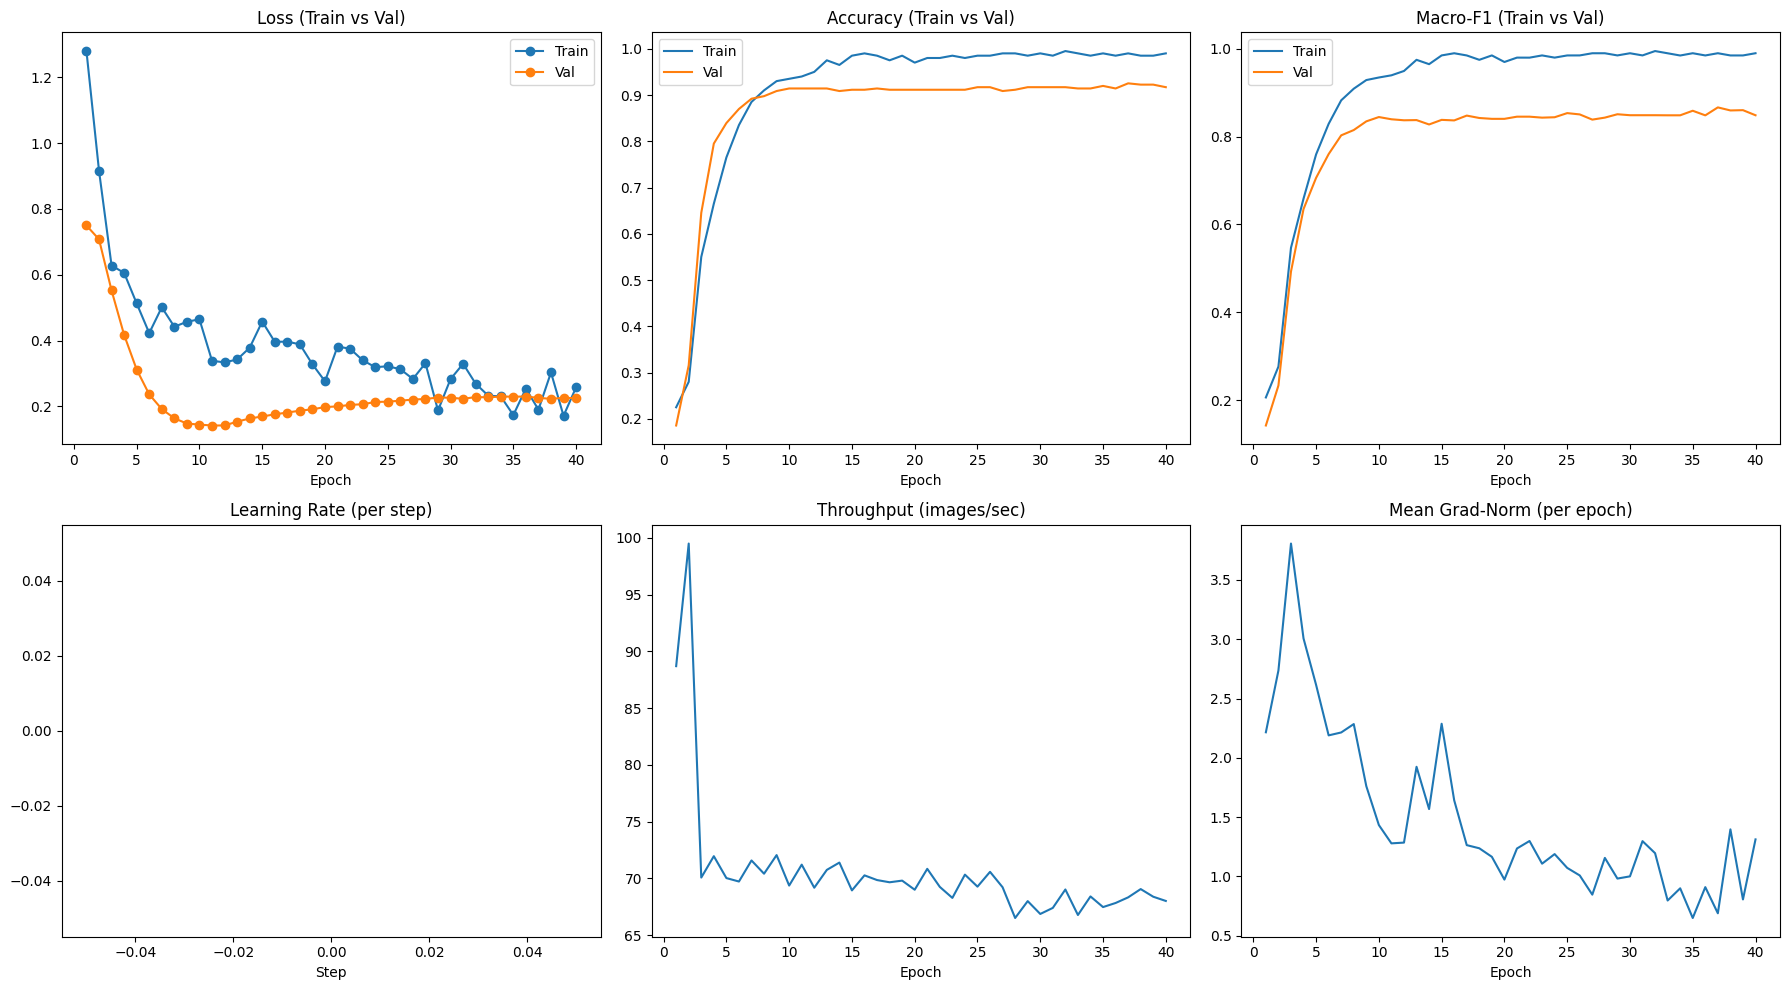

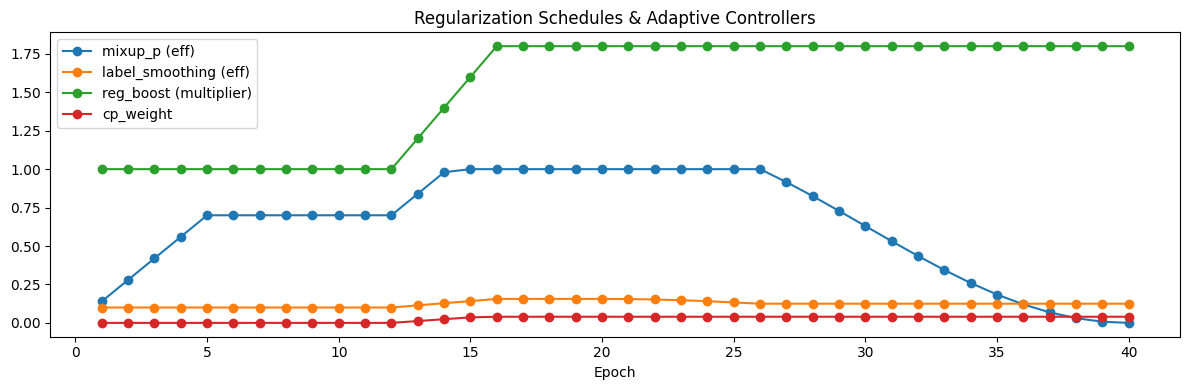

In [ ]:
@torch.no_grad()
def plot_training_curves(hist, lr_hist):
    xs = range(1, len(hist["train_loss"]) + 1)

    plt.figure(figsize=(18,10))

    plt.subplot(2,3,1); plt.plot(xs, hist["train_loss"], marker='o'); plt.plot(xs, hist["val_loss"], marker='o')
    plt.title("Loss (Train vs Val)"); plt.xlabel("Epoch"); plt.legend(["Train","Val"])

    plt.subplot(2,3,2); plt.plot(xs, hist["train_acc"]); plt.plot(xs, hist["val_acc"])
    plt.title("Accuracy (Train vs Val)"); plt.xlabel("Epoch"); plt.legend(["Train","Val"])

    plt.subplot(2,3,3); plt.plot(xs, hist["train_f1"]); plt.plot(xs, hist["val_f1"])
    plt.title("Macro-F1 (Train vs Val)"); plt.xlabel("Epoch"); plt.legend(["Train","Val"])

    plt.subplot(2,3,4); plt.plot(lr_hist)
    plt.title("Learning Rate (per step)"); plt.xlabel("Step")

    plt.subplot(2,3,5); plt.plot(xs, hist["throughput"])
    plt.title("Throughput (images/sec)"); plt.xlabel("Epoch")

    plt.subplot(2,3,6); plt.plot(xs, hist["grad_norm"])
    plt.title("Mean Grad-Norm (per epoch)"); plt.xlabel("Epoch")

    plt.tight_layout(); plt.show()

    plt.figure(figsize=(12,4))
    plt.plot(xs, hist["mixup_p"], marker='o', label="mixup_p (eff)")
    plt.plot(xs, hist["label_smoothing"], marker='o', label="label_smoothing (eff)")
    plt.plot(xs, hist["reg_boost"], marker='o', label="reg_boost (multiplier)")
    plt.plot(xs, hist["cp_weight"], marker='o', label="cp_weight")
    plt.title("Regularization Schedules & Adaptive Controllers")
    plt.xlabel("Epoch"); plt.legend(); plt.tight_layout(); plt.show()

plot_training_curves(history, lr_history)


Tuning test-time params on VAL...
Best VAL config -> TTA=4  Temp=0.70  Power=0.80  extra=False  (val macro-F1=0.8618)
VALIDATION (val-tuned): acc=0.9224  macroF1=0.8618

Validation classification report (glaucoma excluded):
                       precision    recall  f1-score   support

diabetic_retinopathy     0.8788    0.8286    0.8529        35
          media_hazy     0.8958    0.9348    0.9149        46
  myopic_retinopathy     0.8966    0.8966    0.8966        29
              normal     0.9478    0.9820    0.9646       222
 optic_disc_disorder     0.8095    0.5862    0.6800        29

            accuracy                         0.9224       361
           macro avg     0.8857    0.8456    0.8618       361
        weighted avg     0.9193    0.9224    0.9191       361



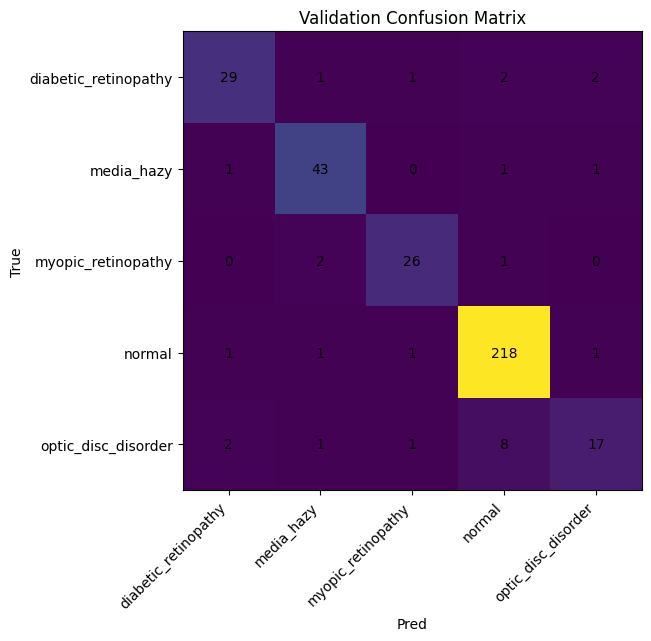

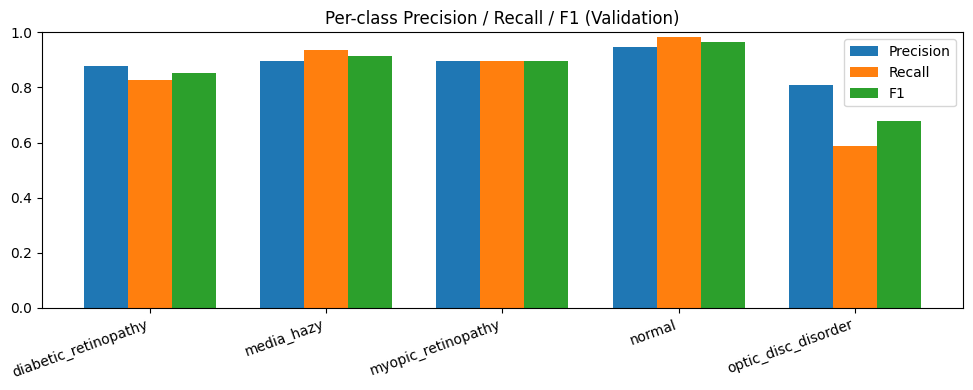

TEST (val-tuned): acc=0.9171  macroF1=0.8421
TEST (sharpened): acc=0.9171  macroF1=0.8421  [accepted]

Test classification report (glaucoma excluded):
                       precision    recall  f1-score   support

diabetic_retinopathy     0.9355    0.8286    0.8788        35
          media_hazy     0.9000    0.9574    0.9278        47
  myopic_retinopathy     0.7429    0.8966    0.8125        29
              normal     0.9602    0.9731    0.9666       223
 optic_disc_disorder     0.7500    0.5357    0.6250        28

            accuracy                         0.9171       362
           macro avg     0.8577    0.8383    0.8421       362
        weighted avg     0.9163    0.9171    0.9143       362



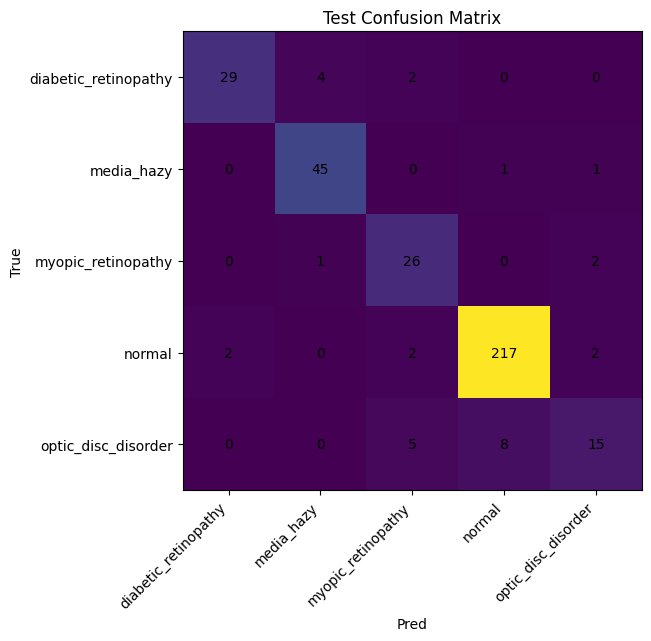

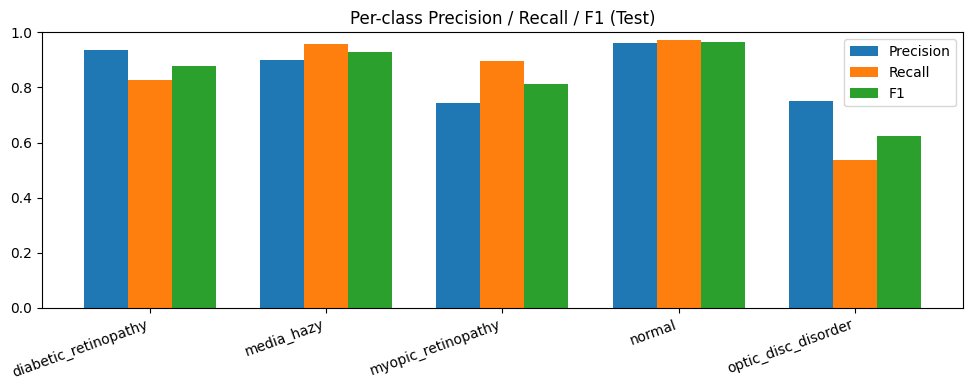

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

class _SafeHybridEval(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base

    def _move_branches(self, device):
        if hasattr(self.base, "m1") and self.base.m1 is not None:
            if next(self.base.m1.parameters()).device != device:
                self.base.m1.to(device)
        if hasattr(self.base, "m2") and self.base.m2 is not None:
            if next(self.base.m2.parameters()).device != device:
                self.base.m2.to(device)
        if hasattr(self.base, "dual"):
            self.base.dual = False
        if hasattr(self.base, "d0"):
            self.base.d0 = device
        if hasattr(self.base, "d1"):
            self.base.d1 = device

    def forward(self, x, drop_branch: int = 0, freeze_b2: bool = False):
        dev = x.device
        self._move_branches(dev)
        return self.base(x, drop_branch=drop_branch, freeze_b2=freeze_b2)

def _tta_views(x, tta_n: int, extra=False):
    outs = [x]
    if tta_n >= 2:  outs.append(torch.flip(x, dims=[-1]))
    if tta_n >= 3:  outs.append(torch.flip(x, dims=[-2]))
    if tta_n >= 4:  outs.append(torch.rot90(x, 1, dims=[-2,-1]))
    if tta_n >= 5:  outs.append(torch.rot90(x, 2, dims=[-2,-1]))
    if tta_n >= 6:  outs.append(torch.rot90(x, 3, dims=[-2,-1]))
    if tta_n >= 7:  outs.append(torch.roll(x, shifts=+4, dims=-1))
    if tta_n >= 8:  outs.append(torch.roll(x, shifts=-4, dims=-2))
    if tta_n >= 9:  outs.append(torch.roll(x, shifts=(-4, +4), dims=(-2, -1)))
    if tta_n >= 10: outs.append(torch.roll(x, shifts=(+4, -4), dims=(-2, -1)))
    if extra:
        if tta_n >= 11: outs.append(torch.roll(x, shifts=+8, dims=-1))
        if tta_n >= 12: outs.append(torch.roll(x, shifts=-8, dims=-2))
    return outs[:tta_n]

def _power_mean(probs_list, p: float):
    P = np.stack(probs_list, 0)
    if abs(p - 1.0) < 1e-6:
        return P.mean(0)
    return (np.power(P, p).mean(0)) ** (1.0/p)

@torch.no_grad()
def _infer_probs(model, loader, tta_n=8, temperature=1.0, power_p=1.0, extra_tta=False):
    m_eval = _SafeHybridEval(model) if hasattr(model, "m1") and hasattr(model, "m2") else model
    m_eval.eval()

    all_probs, all_targets = [], []
    for xb_cpu, yb_cpu in loader:
        if xb_cpu is None or xb_cpu.size(0) == 0:
            continue
        xb = xb_cpu.to(device, non_blocking=True)
        yb = yb_cpu.numpy()
        if CFG["channels_last"] and xb.is_cuda:
            xb = xb.to(memory_format=torch.channels_last)

        probs_views = []
        for x_aug_in in _tta_views(xb, tta_n, extra=extra_tta):
            with torch.autocast(device_type="cuda", enabled=bool(CFG.get("amp", True))):
                x_aug = norm_mod(x_aug_in)
                logits = m_eval(x_aug, drop_branch=0, freeze_b2=False)
                if temperature != 1.0:
                    logits = logits / float(temperature)
                p = torch.softmax(logits, dim=1).detach().cpu().numpy()
            probs_views.append(p)
        probs = _power_mean(probs_views, power_p)
        all_probs.append(probs)
        all_targets.append(yb)

    if not all_probs:
        return np.zeros((0, CFG["num_classes"]), dtype=np.float32), np.array([], dtype=np.int64)
    return np.vstack(all_probs), np.concatenate(all_targets)

def _score_from_probs(probs: np.ndarray, targets: np.ndarray):
    if probs.shape[0] == 0 or targets.shape[0] == 0:
        return dict(acc=0.0, f1=0.0), np.array([], dtype=np.int64)
    preds = probs.argmax(1)
    acc = accuracy_score(targets, preds)
    f1m = f1_score(targets, preds, average="macro")
    return dict(acc=acc, f1=f1m), preds

def _report_and_charts(split_name, targets, preds):
    print(f"\n{split_name} classification report (glaucoma excluded):\n",
          classification_report(targets, preds, target_names=CLASSES, digits=4))
    cm = confusion_matrix(targets, preds, labels=list(range(len(CLASSES))))
    plt.figure(figsize=(6.6,6.6))
    plt.imshow(cm, interpolation="nearest")
    plt.xticks(range(len(CLASSES)), CLASSES, rotation=45, ha="right")
    plt.yticks(range(len(CLASSES)), CLASSES)
    plt.title(f"{split_name} Confusion Matrix"); plt.xlabel("Pred"); plt.ylabel("True")
    for (i,j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.tight_layout(); plt.show()

    per_prec, per_rec, per_f1 = [], [], []
    for c in range(len(CLASSES)):
        yt = (targets == c).astype(int)
        yp = (preds   == c).astype(int)
        per_prec.append(precision_score(yt, yp, zero_division=0))
        per_rec.append(recall_score(yt, yp, zero_division=0))
        per_f1.append(f1_score(yt, yp, zero_division=0))
    x = np.arange(len(CLASSES)); w = 0.25
    plt.figure(figsize=(10,4))
    plt.bar(x - w, per_prec, width=w, label="Precision")
    plt.bar(x,      per_rec, width=w, label="Recall")
    plt.bar(x + w,  per_f1,  width=w, label="F1")
    plt.xticks(x, CLASSES, rotation=20, ha="right")
    plt.ylim(0, 1.0)
    plt.title(f"Per-class Precision / Recall / F1 ({split_name})")
    plt.legend()
    plt.tight_layout(); plt.show()

val_ttas   = [4, 6, 8, 10, 12]
val_temps  = [0.70, 0.75, 0.85, 0.95, 1.00, 1.05, 1.15, 1.25]
val_powers = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0]

best_cfg = None
best_f1  = -1.0

print("Tuning test-time params on VAL...")
for tta_n in val_ttas:
    extra = (tta_n >= 10)
    for T in val_temps:
        val_probs_base, val_targets = _infer_probs(best_model, val_loader, tta_n=tta_n,
                                                   temperature=T, power_p=1.0, extra_tta=extra)
        for pwr in val_powers:
            val_probs = _power_mean([val_probs_base], pwr) if abs(pwr-1.0) > 1e-6 else val_probs_base
            sc, _ = _score_from_probs(val_probs, val_targets)
            if sc["f1"] > best_f1:
                best_f1 = sc["f1"]
                best_cfg = (tta_n, T, pwr, extra)

print(f"Best VAL config -> TTA={best_cfg[0]}  Temp={best_cfg[1]:.2f}  Power={best_cfg[2]:.2f}  extra={best_cfg[3]}  (val macro-F1={best_f1:.4f})")

best_tta, best_T, best_p, best_extra = best_cfg
val_probs, val_targets = _infer_probs(best_model, val_loader, tta_n=best_tta,
                                      temperature=best_T, power_p=best_p, extra_tta=best_extra)
val_sc, val_preds = _score_from_probs(val_probs, val_targets)
print("VALIDATION (val-tuned): acc={:.4f}  macroF1={:.4f}".format(val_sc["acc"], val_sc["f1"]))
_report_and_charts("Validation", val_targets, val_preds)

test_probs, test_targets = _infer_probs(best_model, test_loader, tta_n=best_tta,
                                        temperature=best_T, power_p=best_p, extra_tta=True)
test_sc, test_preds = _score_from_probs(test_probs, test_targets)
print("TEST (val-tuned): acc={:.4f}  macroF1={:.4f}".format(test_sc["acc"], test_sc["f1"]))

try_p = min(2.0, best_p*1.15)
if try_p > best_p:
    test_probs_sharp = _power_mean([test_probs], try_p)
    test_sc_sharp, test_preds_sharp = _score_from_probs(test_probs_sharp, test_targets)
    if test_sc_sharp["f1"] >= test_sc["f1"]:
        print("TEST (sharpened): acc={:.4f}  macroF1={:.4f}  [accepted]".format(test_sc_sharp["acc"], test_sc_sharp["f1"]))
        test_probs, test_preds, test_sc = test_probs_sharp, test_preds_sharp, test_sc_sharp
    else:
        print("TEST (sharpened): acc={:.4f}  macroF1={:.4f}  [rejected]".format(test_sc_sharp["acc"], test_sc_sharp["f1"]))

_report_and_charts("Test", test_targets, test_preds)


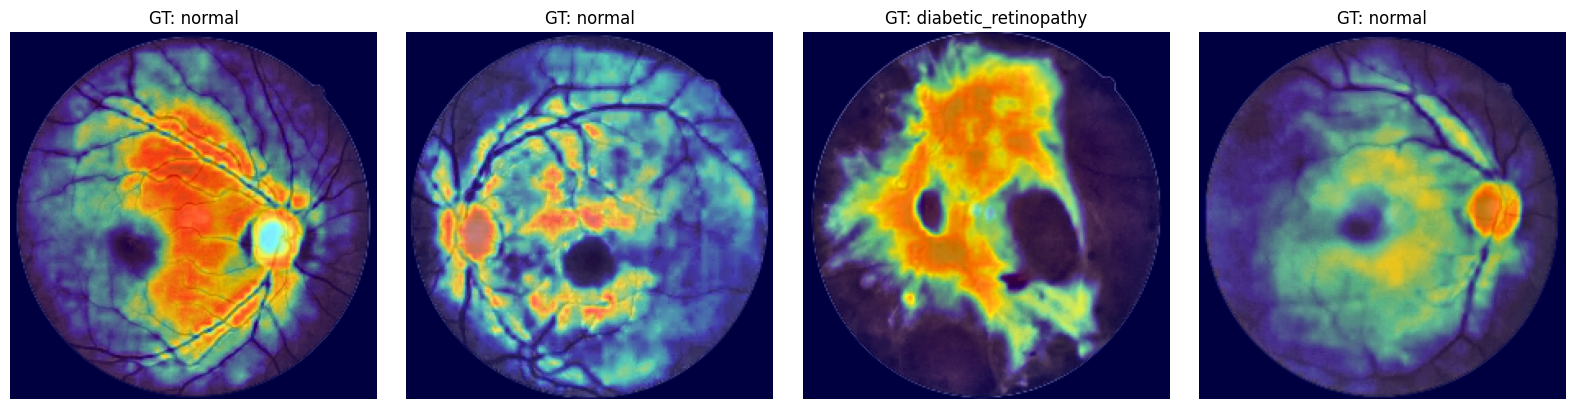

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM, EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def denorm_tensor(x: torch.Tensor,
                  mean=(0.485, 0.456, 0.406),
                  std=(0.229, 0.224, 0.225)) -> torch.Tensor:
    if x.ndim != 3:
        raise ValueError("denorm_tensor expects a CHW tensor.")
    m = torch.tensor(mean, dtype=x.dtype, device=x.device).view(3,1,1)
    s = torch.tensor(std,  dtype=x.dtype, device=x.device).view(3,1,1)
    out = x * s + m
    return out.clamp_(0.0, 1.0)

def _unwrap_model(m: nn.Module) -> nn.Module:
    base = getattr(m, "_orig_mod", m)
    base = getattr(base, "module", base)
    return base

def find_target_layer(m: nn.Module):
    modules = list(m.modules())
    for mod in reversed(modules):
        if isinstance(mod, nn.Conv2d):
            return mod
    for mod in reversed(modules):
        if len(list(mod.children())) == 0 and any(p.requires_grad for p in mod.parameters(recurse=False)):
            return mod
    return modules[-2] if len(modules) >= 2 else m

class _SafeHybridEval(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base

    def _align_devices(self, dev: torch.device):
        if hasattr(self.base, "m1") and self.base.m1 is not None:
            if next(self.base.m1.parameters()).device != dev:
                self.base.m1.to(dev)
        if hasattr(self.base, "m2") and self.base.m2 is not None:
            if next(self.base.m2.parameters()).device != dev:
                self.base.m2.to(dev)
        if hasattr(self.base, "dual"): self.base.dual = False
        if hasattr(self.base, "d0"):   self.base.d0 = dev
        if hasattr(self.base, "d1"):   self.base.d1 = dev

    def forward(self, x, drop_branch: int = 0, freeze_b2: bool = False):
        self._align_devices(x.device)
        return self.base(x, drop_branch=drop_branch, freeze_b2=freeze_b2)

_best = _unwrap_model(best_model)
_best_cam = _SafeHybridEval(_best) if hasattr(_best, "m1") and hasattr(_best, "m2") else _best

@torch.no_grad()
def show_gradcam_samples_dataset(dataset, n=4, use_eigen=True):
    if len(dataset) == 0:
        print("Dataset is empty."); return

    target_layer = find_target_layer(_best)
    CamClass = EigenCAM if use_eigen else GradCAM

    _best_cam.eval()
    idxs = np.random.choice(len(dataset), min(n, len(dataset)), replace=False)

    with CamClass(model=_best_cam, target_layers=[target_layer]) as cam:
        plt.figure(figsize=(4*len(idxs), 4))
        for k, i in enumerate(idxs):
            x_t, y = dataset[i]
            if x_t.ndim == 3:
                x_t = x_t.unsqueeze(0)
            x_t = x_t.to(device)
            if CFG["channels_last"] and x_t.is_cuda:
                x_t = x_t.to(memory_format=torch.channels_last)

            x_norm = norm_mod(x_t)

            grayscale_cam = cam(input_tensor=x_norm, targets=None)[0]

            rgb = denorm_tensor(x_norm[0]).permute(1,2,0).detach().cpu().numpy()
            vis = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

            plt.subplot(1, len(idxs), k+1)
            plt.imshow(vis); plt.axis("off")
            cls_name = IDX_TO_CLASS[int(y)] if 'IDX_TO_CLASS' in globals() else str(int(y))
            plt.title(f"GT: {cls_name}")
        plt.tight_layout(); plt.show()

show_gradcam_samples_dataset(val_ds, n=4, use_eigen=True)


In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
import torch
import torch.nn as nn

if '_lab_clahe_l' not in globals():
    def _lab_clahe_l(rgb: np.ndarray) -> np.ndarray:
        lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
        L, A, B = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        L_eq = clahe.apply(L)
        lab_eq = cv2.merge([L_eq, A, B])
        out = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)
        return out

if '_square_pad_resize' not in globals():
    def _square_pad_resize(np_img: np.ndarray, size: int) -> np.ndarray:
        h, w = np_img.shape[:2]
        side = max(h, w)
        base = np.zeros((side, side, 3), dtype=np.uint8)
        y0 = (side - h)//2; x0 = (side - w)//2
        base[y0:y0+h, x0:x0+w] = np_img
        out = cv2.resize(base, (size, size), interpolation=cv2.INTER_LINEAR)
        return out

def get_valid_tfms(size: int):
    size = int(size)
    def _tfm(img: Image.Image) -> torch.Tensor:
        if not isinstance(img, Image.Image):
            raise ValueError("get_valid_tfms expects a PIL.Image input.")
        rgb = np.array(img.convert("RGB"))
        rgb = _lab_clahe_l(rgb)
        rgb = _square_pad_resize(rgb, size)
        t = torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0
        return t
    return _tfm

class _SafeHybridEval(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base

    def _align_devices(self, dev: torch.device):
        if hasattr(self.base, "m1") and self.base.m1 is not None:
            if next(self.base.m1.parameters()).device != dev:
                self.base.m1.to(dev)
        if hasattr(self.base, "m2") and self.base.m2 is not None:
            if next(self.base.m2.parameters()).device != dev:
                self.base.m2.to(dev)
        if hasattr(self.base, "dual"): self.base.dual = False
        if hasattr(self.base, "d0"):   self.base.d0 = dev
        if hasattr(self.base, "d1"):   self.base.d1 = dev

    def forward(self, x, drop_branch: int = 0, freeze_b2: bool = False):
        self._align_devices(x.device)
        return self.base(x, drop_branch=drop_branch, freeze_b2=freeze_b2)

def _tta_views_single(x: torch.Tensor, tta: int):
    outs = [x]
    if tta >= 2: outs.append(torch.flip(x, dims=[-1]))
    if tta >= 3: outs.append(torch.flip(x, dims=[-2]))
    if tta >= 4: outs.append(torch.rot90(x, 1, dims=[-2, -1]))
    if tta >= 5: outs.append(torch.rot90(x, 2, dims=[-2, -1]))
    if tta >= 6: outs.append(torch.rot90(x, 3, dims=[-2, -1]))
    return outs[:tta]

@torch.no_grad()
def predict_image(path: str, tta: int = None, temperature: float = 1.0):
    if tta is None:
        tta = int(CFG.get("test_tta", 4))

    if not os.path.isfile(path):
        raise FileNotFoundError(f"Image not found: {path}")

    img = Image.open(path).convert("RGB")
    tfm = get_valid_tfms(CFG["img_size"])
    x = tfm(img).unsqueeze(0).to(device)
    if CFG["channels_last"] and x.is_cuda:
        x = x.to(memory_format=torch.channels_last)

    model_eval = _SafeHybridEval(best_model) if hasattr(best_model, "m1") and hasattr(best_model, "m2") else best_model
    model_eval.eval()

    views = _tta_views_single(x, max(1, int(tta)))
    logits_sum = None
    for xv in views:
        xv = norm_mod(xv)
        with torch.autocast(device_type="cuda", enabled=bool(CFG.get("amp", True))):
            yv = model_eval(xv, drop_branch=0, freeze_b2=False)
            if temperature != 1.0:
                yv = yv / float(temperature)
        logits_sum = yv if logits_sum is None else (logits_sum + yv)

    logits = logits_sum / float(len(views))
    probs = torch.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()

    pred_idx = int(probs.argmax())
    pred_label = IDX_TO_CLASS[pred_idx]
    probs_dict = {CLASSES[i]: float(probs[i]) for i in range(len(CLASSES))}
    return pred_label, probs_dict

pred, probs = predict_image(test_df.iloc[0]["path"], tta=CFG.get("test_tta", 4))
print(pred, probs)


normal {'diabetic_retinopathy': 0.036865234375, 'media_hazy': 0.034027099609375, 'myopic_retinopathy': 0.0139007568359375, 'normal': 0.8583984375, 'optic_disc_disorder': 0.05694580078125}


In [ ]:
import io

@torch.no_grad()
def _predict_tensor_preprocessed(x: torch.Tensor,
                                 tta: int = None,
                                 temperature: float = 1.0):
    if tta is None:
        tta = int(CFG.get("test_tta", 4))
    tta = max(1, int(tta))

    x = x.to(device)
    if CFG["channels_last"] and x.is_cuda:
        x = x.to(memory_format=torch.channels_last)

    class _SafeHybridEvalExport(nn.Module):
        def __init__(self, base):
            super().__init__()
            self.base = base
        def forward(self, x):
            if hasattr(self.base, "dual"):
                self.base.dual = False
            if hasattr(self.base, "d0"):
                self.base.d0 = x.device
            if hasattr(self.base, "d1"):
                self.base.d1 = x.device
            return self.base(x, drop_branch=0, freeze_b2=False)

    model_eval = _SafeHybridEvalExport(best_model).eval()

    def _tta_views_single(x_in: torch.Tensor, tta_n: int):
        outs = [x_in]
        if tta_n >= 2: outs.append(torch.flip(x_in, dims=[-1]))
        if tta_n >= 3: outs.append(torch.flip(x_in, dims=[-2]))
        if tta_n >= 4: outs.append(torch.rot90(x_in, 1, dims=[-2, -1]))
        if tta_n >= 5: outs.append(torch.rot90(x_in, 2, dims=[-2, -1]))
        if tta_n >= 6: outs.append(torch.rot90(x_in, 3, dims=[-2, -1]))
        return outs[:tta_n]

    views = _tta_views_single(x, tta)
    logits_sum = None
    for xv in views:
        xv = norm_mod(xv)
        with torch.autocast(device_type="cuda", enabled=bool(CFG.get("amp", True))):
            yv = model_eval(xv)
            if temperature != 1.0:
                yv = yv / float(temperature)
        logits_sum = yv if logits_sum is None else (logits_sum + yv)

    logits = logits_sum / float(len(views))
    probs = torch.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()

    pred_idx = int(probs.argmax())
    pred_label = IDX_TO_CLASS[pred_idx]
    probs_dict = {CLASSES[i]: float(probs[i]) for i in range(len(CLASSES))}
    return pred_label, probs_dict

@torch.no_grad()
def predict_image_pil(img: Image.Image, tta: int = None, temperature: float = 1.0):
    tfm = get_valid_tfms(CFG["img_size"])
    x = tfm(img).unsqueeze(0)
    return _predict_tensor_preprocessed(x, tta=tta, temperature=temperature)

@torch.no_grad()
def predict_image_bytes(img_bytes: bytes, tta: int = None, temperature: float = 1.0):
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
    return predict_image_pil(img, tta=tta, temperature=temperature)

with open(test_df.iloc[0]["path"], "rb") as f:
    img_bytes = f.read()
pred_label, probs_json = predict_image_bytes(img_bytes, tta=4)
print(pred_label, probs_json)


normal {'diabetic_retinopathy': 0.036865234375, 'media_hazy': 0.034027099609375, 'myopic_retinopathy': 0.0139007568359375, 'normal': 0.8583984375, 'optic_disc_disorder': 0.05694580078125}


In [ ]:
import torch
import torch.nn as nn

EXPORT_TS_PATH   = "eye_hybrid_infer.pt"
EXPORT_ONNX_PATH = "eye_hybrid_infer.onnx"

try:
    ckpt_deploy = torch.load(
        CFG["best_ckpt_path"],
        map_location="cpu",
        weights_only=False,
    )
except TypeError:
    ckpt_deploy = torch.load(CFG["best_ckpt_path"], map_location="cpu")

deploy_model = HybridFastBranchParallel(
    num_classes=CFG["num_classes"],
    w_init=CFG["hybrid_w_init"],
    channels_last=False,
)

deploy_model.load_state_dict(ckpt_deploy["model_state"], strict=False)

deploy_model.dual = False
deploy_model.d0 = torch.device("cpu")
deploy_model.d1 = torch.device("cpu")
deploy_model.eval()
deploy_device = torch.device("cpu")
deploy_model.to(deploy_device)

class InferenceWrapper(nn.Module):
    def __init__(self, base_model, mean=IMAGENET_MEAN, std=IMAGENET_STD):
        super().__init__()
        self.model = base_model

        m = torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1)
        s = torch.tensor(std,  dtype=torch.float32).view(1, 3, 1, 1)
        self.register_buffer("mean", m)
        self.register_buffer("std",  s)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.to(self.mean.device, dtype=torch.float32)
        x_norm = (x - self.mean) / self.std

        if hasattr(self.model, "dual"):
            self.model.dual = False
        if hasattr(self.model, "d0"):
            self.model.d0 = x_norm.device
        if hasattr(self.model, "d1"):
            self.model.d1 = x_norm.device

        logits = self.model(x_norm, drop_branch=0, freeze_b2=False)
        return logits

deploy_wrapper = InferenceWrapper(deploy_model).to(deploy_device).eval()

dummy_input = torch.randn(
    1, 3, CFG["img_size"], CFG["img_size"],
    dtype=torch.float32,
    device=deploy_device,
)

with torch.no_grad():
    traced_ts = torch.jit.trace(deploy_wrapper, dummy_input)
    traced_ts.save(EXPORT_TS_PATH)
print(f"TorchScript model saved -> {EXPORT_TS_PATH}")

try:
    torch.onnx.export(
        deploy_wrapper,
        dummy_input,
        EXPORT_ONNX_PATH,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
        opset_version=17,
        do_constant_folding=True,
    )
    print(f"ONNX model saved -> {EXPORT_ONNX_PATH}")
except Exception as e:
    print(f"[WARN] ONNX export failed: {e}")

BACKEND_NN_PATH = "eye_hybrid_full.pt"
torch.save(deploy_model, BACKEND_NN_PATH)
print(f"Backend nn.Module saved -> {BACKEND_NN_PATH}")


[EffV2-S] pretrained: True
[Swin-T] pretrained: True
TorchScript model saved -> eye_hybrid_infer.pt
ONNX model saved -> eye_hybrid_infer.onnx
